# **Tutorial #2: Simulating the $LiH$ Potential Energy Surface**

**Goal:** It computes the ground-state energy
of Lithium Hydride (LiH) as a function of bond distance using
the Variational Quantum Eigensolver (VQE) with UCCSD ansatz.

In [1]:
# 1. Install required packages (only needed in Colab)
!pip install -q qiskit qiskit-aer qiskit-nature qiskit-nature-pyscf pyscf qiskit-algorithms

In [2]:
# 2. Imports
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.units import DistanceUnit

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import StatevectorEstimator

# For noise simulation (optional)
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [3]:
# 3. Setup global tools
mapper = JordanWignerMapper()
optimizer = SLSQP(maxiter=200)
estimator = StatevectorEstimator()   # noiseless
# Optional: noisy estimator (uncomment to use)
# noise_model = NoiseModel()
# error = depolarizing_error(0.001, 2)  # 0.1% depolarizing error on 2-qubit gates
# noise_model.add_all_qubit_quantum_error(error, ['cx'])
# noisy_backend = AerSimulator(noise_model=noise_model)
# from qiskit.primitives import BackendEstimator
# estimator = BackendEstimator(backend=noisy_backend)

In [4]:
# 4. Define bond distances (Angstroms) – LiH equilibrium ~1.6 Å
distances = np.linspace(1, 2.5, 8)   # 8 points from 1.0 to 3.5 Å
energies = []

print("Starting LiH Potential Energy Surface Scan...")
print(f"{'Distance (Å)':<15} | {'Total Energy (Hartree)':<25}")
print("-" * 45)


# 5. Loop over distances and run VQE
for d in distances:
    # A. Define LiH molecule at distance d
    driver = PySCFDriver(
        atom=f"Li 0 0 0; H 0 0 {d}",
        basis="sto3g",
        charge=0,
        spin=0,               # singlet ground state
        unit=DistanceUnit.ANGSTROM,
    )
    problem = driver.run()

    transformer = FreezeCoreTransformer(
        freeze_core=True,
        remove_orbitals=[-3, -2]   # freeze the two lowest orbitals
        )
    problem = transformer.transform(problem)

    # Map fermionic Hamiltonian to qubit operator
    hamiltonian = problem.hamiltonian.second_q_op()
    qubit_op = mapper.map(hamiltonian)

    # B. Prepare initial state (Hartree-Fock) and UCCSD ansatz
    init_state = HartreeFock(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
    )
    ansatz = UCCSD(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
        initial_state=init_state,
    )

    # C. Run VQE
    vqe = VQE(estimator, ansatz, optimizer)
    vqe.initial_point = np.zeros(ansatz.num_parameters)   # start from zeros
    result = vqe.compute_minimum_eigenvalue(qubit_op)

    # D. Total energy = electronic + nuclear repulsion
    total_energy = result.eigenvalue.real + problem.nuclear_repulsion_energy
    energies.append(total_energy)

    print(f"{d:<15.2f} | {total_energy:<25.6f}")


Starting LiH Potential Energy Surface Scan...
Distance (Å)    | Total Energy (Hartree)   
---------------------------------------------


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


1.00            | 0.413295                 
1.21            | 0.152097                 
1.43            | -0.004196                
1.64            | -0.102166                
1.86            | -0.166022                
2.07            | -0.209434                
2.29            | -0.240647                
2.50            | -0.264897                


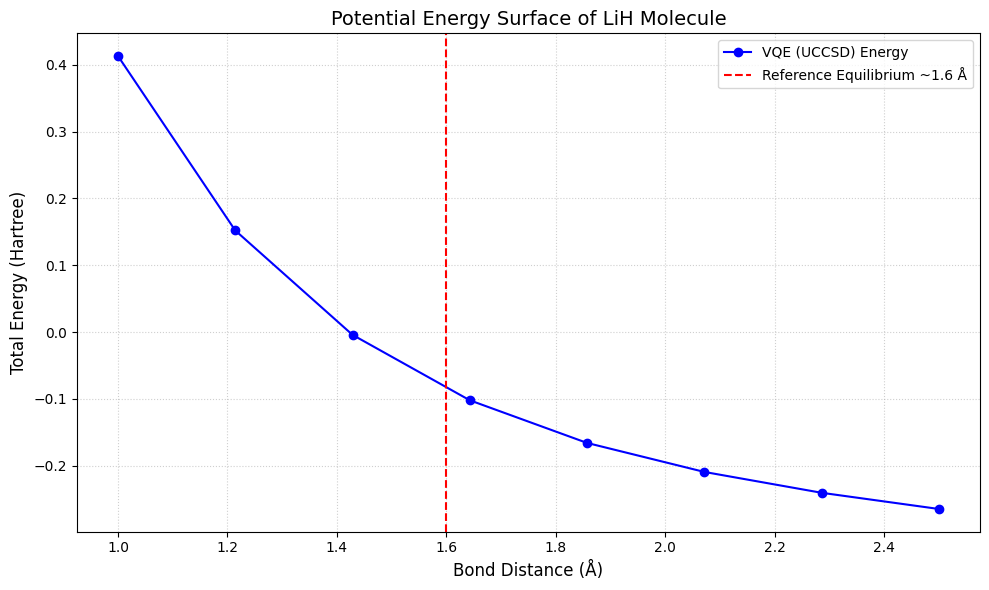

In [5]:
# 6. Plot the Potential Energy Surface
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(distances, energies, 'bo-', label='VQE (UCCSD) Energy')
plt.axvline(x=1.6, color='r', linestyle='--', label='Reference Equilibrium ~1.6 Å')
plt.title('Potential Energy Surface of LiH Molecule', fontsize=14)
plt.xlabel('Bond Distance (Å)', fontsize=12)
plt.ylabel('Total Energy (Hartree)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [6]:
# 7. Optional: Save plot to file (download to local machine or GitHub)
plt.savefig('lih_pes.png', dpi=150)
print("\nPlot saved as 'lih_pes.png'. Download it from Colab (Files tab) and upload to your GitHub repo.")


Plot saved as 'lih_pes.png'. Download it from Colab (Files tab) and upload to your GitHub repo.


<Figure size 640x480 with 0 Axes>